<a href="https://colab.research.google.com/github/saverin0/Change-Detection-Using-Dinov3/blob/main/04_embedding_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SpaceNet-7 Temporal Change Detection with DINOv3
## Part 4: Working with the Embeddings Directly

### What this notebook does
Parts 2 and 3 treat the DINOv3 patch features as **inputs to a trained model**. But the features are *embeddings*: vectors whose distances carry meaning. That makes them useful on their own, with no training at all. This notebook uses them that way:

| Step | Analysis | What it tells us |
|---|---|---|
| 7 | **Cosine-distance change baseline**: how far did each patch's embedding move between two months? | How much of the trained model's score comes from the embeddings themselves |
| 8 | **Cluster-switch change baseline**: k-means on all patches; did a patch change cluster? | A second, discrete training-free detector |
| 9 | **Embedding maps over time**: the top-3 PCA components shown as RGB | Whether embeddings are stable month to month, and where they aren't |
| 10 | **Similarity search by example** | Whether "find me more like this new construction" works in embedding space |
| 11 | **Comparison of every run** and the baselines, saved to Drive | The final results table for the README |

### Best practices for embeddings, and how they apply here
This follows the guidance in Esri's *Including Embeddings in Your Spatial Analysis Workflows*:

| Guidance | How it's applied |
|---|---|
| **Use embeddings at the scale of the analysis.** | One embedding per 16×16 px patch (~75 m). Labels are compared at 128×128 cells (~32 m); each patch's score is upsampled to that grid rather than the labels being pooled further. |
| **Aggregate with caution: averaging embeddings can lose information.** | Patches are never averaged over space or time. Each comparison is between a patch and *itself* in another month. |
| **Don't standardize embeddings; they're already on a meaningful scale.** | PCA-projected features are used as saved. Cosine distance is used because it ignores overall vector length and treats every dimension equally. |
| **Don't mix embeddings with traditional variables in similarity metrics.** | Similarity and clustering use the embedding vectors only. |
| **Embeddings plus a task-specific model beat either alone.** | That's Part 3. Here we measure the gap between the raw embeddings and the trained model. |

### Before you run
1. **Run Parts 1 and 2.** Part 3 is needed only for the comparison table (Step 11); the rest works without it.
2. A **CPU runtime is enough**. A GPU speeds up the similarity computations slightly.
3. RAM: all features (~3 GB) are loaded into memory, as in Part 3.

## Step 1: Mount Google Drive

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## Step 2: Import libraries

Everything used here ships with Colab: NumPy, PyTorch (for fast batched math, on CPU or GPU), scikit-learn (k-means), and Matplotlib. **rasterio** (for the image panels) and **scikit-learn** are installed if missing.

In [3]:
import importlib.util
import subprocess
import sys

missing = [pkg for pkg, module in [("rasterio", "rasterio"), ("scikit-learn", "sklearn")]
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import json
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio
import torch
import torch.nn.functional as F
from rasterio.enums import Resampling
from sklearn.cluster import MiniBatchKMeans
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__} | device: {device}")

torch 2.11.0+cpu | device: cpu


## Step 3: Configuration

Paths come from Part 1's `config.json`. `FEATURES_SUBDIR` picks which Part 2 features to analyse (the default is the 64×64 PCA features used by the best Part 3 run). Outputs go to `training/embedding_analysis/` on Drive.

In [4]:
CACHE_BASE = Path("/content/drive/MyDrive/datasets/spacenet7_cache")
FEATURES_SUBDIR = "features_1024_pca256"
N_CLUSTERS = 8
SEED = 42

config_path = CACHE_BASE / "config.json"
if not config_path.exists():
    raise FileNotFoundError(f"{config_path} not found. Run Part 1 first, with the same cache_base.")
config = json.loads(config_path.read_text())

DATA_ROOT = Path(config["data_root"])
CACHE_DIR = Path(config["cache_dir"])
LABELS_DIR = CACHE_DIR / "labels"
MASKS_DIR = CACHE_DIR / "masks"
FEATURES_DIR = CACHE_DIR / FEATURES_SUBDIR
SPLIT_PATH = CACHE_DIR / "training" / "split.json"
TRAINING_DIR = CACHE_DIR / "training"
OUTPUT_DIR = TRAINING_DIR / "embedding_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_RES = config["output_resolution"]

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Features: {FEATURES_DIR}")
print(f"Outputs: {OUTPUT_DIR}")

Features: /content/drive/MyDrive/datasets/spacenet7_cache/features_1024_pca256
Outputs: /content/drive/MyDrive/datasets/spacenet7_cache/training/embedding_analysis


## Step 4: Load features, labels, cloud masks, and the split

Same loading as Part 3: features stay float16, targets are max-pooled to 128×128, and each location's `months` must agree across the three files. The split from Part 1 (Step 14) is reused so the baselines are scored on **exactly the same test locations** as the trained models.

In [5]:
def max_pool_masks(masks, size):
    pooled = F.adaptive_max_pool2d(torch.from_numpy(masks).float().unsqueeze(1), size)
    return pooled.squeeze(1).to(torch.uint8)


def load_location(loc_id):
    with np.load(FEATURES_DIR / f"{loc_id}_features.npz") as f:
        features = torch.from_numpy(f["features"])
        feature_months = [str(m) for m in f["months"]]
    with np.load(LABELS_DIR / f"{loc_id}_labels.npz", allow_pickle=True) as labels:
        months = [str(m) for m in labels["months"]]
        change = max_pool_masks(labels["pixel_change_masks"], OUTPUT_RES)
    with np.load(MASKS_DIR / f"{loc_id}_masks.npz") as m:
        masked = torch.from_numpy(m["masked"])
        mask_months = [str(month) for month in m["months"]]
    if feature_months != months or mask_months != months:
        raise ValueError(f"{loc_id}: months differ between features, labels, and masks")
    return {"features": features, "change": change, "months": months,
            "keep": ~(masked[:-1] | masked[1:])}


if not SPLIT_PATH.exists():
    raise FileNotFoundError(f"{SPLIT_PATH} not found. Run Part 1 (Step 14).")
split = json.loads(SPLIT_PATH.read_text())
location_ids = sorted(sum(split.values(), []))
missing = [i for i in location_ids if not (FEATURES_DIR / f"{i}_features.npz").exists()]
if missing:
    raise FileNotFoundError(f"{len(missing)} locations have no features in {FEATURES_DIR}. Run Part 2.")

with ThreadPoolExecutor(max_workers=6) as pool:
    data = dict(zip(location_ids, tqdm(pool.map(load_location, location_ids), total=len(location_ids), desc="Loading")))

GRID = next(iter(data.values()))["features"].shape[1]
FEATURE_DIM = next(iter(data.values()))["features"].shape[-1]
print(f"Loaded {len(data)} locations | grid {GRID}x{GRID} x {FEATURE_DIM} | split: "
      + ", ".join(f"{k} {len(v)}" for k, v in split.items()))

Loading:   0%|          | 0/60 [00:00<?, ?it/s]

Loaded 60 locations | grid 64x64 x 256 | split: train 42, val 9, test 9


## Step 5: Metrics

The same pixel-level metrics as Part 3, computed only on **kept** pixels (not cloud-masked in either month of a pair): precision, recall, F1, IoU.

A training-free detector produces a *score* per patch rather than a probability, so the decision threshold is chosen from the score distribution: 40 candidate thresholds spread over the **validation** scores (from the 50th to the 99.9th percentile), the one with the best validation F1 is picked, and the **test** locations are scored at that threshold. Validation is used for the choice, test only once, exactly as in Part 3.

In [6]:
def scores_at(tp, fp, fn):
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    iou = tp / (tp + fp + fn) if tp + fp + fn else 0.0
    return {"precision": precision, "recall": recall, "f1": f1, "iou": iou}


def count_at_thresholds(score_maps, loc_ids, thresholds):
    """score_maps[loc_id]: (T-1, 128, 128) float tensor. Returns tp/fp/fn per threshold."""
    thresholds = torch.as_tensor(thresholds, dtype=torch.float32, device=device)
    tp = torch.zeros(len(thresholds), dtype=torch.float64, device=device)
    fp, fn = torch.zeros_like(tp), torch.zeros_like(tp)
    for loc_id in loc_ids:
        keep = data[loc_id]["keep"].to(device)
        scores = score_maps[loc_id].to(device)[keep]
        positive = data[loc_id]["change"].to(device)[keep].bool()
        predicted = scores[None, :] > thresholds[:, None]
        tp += (predicted & positive).sum(1).double()
        fp += (predicted & ~positive).sum(1).double()
        fn += (~predicted & positive).sum(1).double()
    return tp.cpu(), fp.cpu(), fn.cpu()


def evaluate_detector(score_maps, name):
    val_scores = torch.cat([score_maps[i][data[i]["keep"]] for i in split["val"]]).float()
    thresholds = torch.quantile(val_scores, torch.linspace(0.50, 0.999, 40)).unique()
    tp, fp, fn = count_at_thresholds(score_maps, split["val"], thresholds)
    per_threshold = [scores_at(float(a), float(b), float(c)) for a, b, c in zip(tp, fp, fn)]
    best = max(range(len(thresholds)), key=lambda i: per_threshold[i]["f1"])
    threshold = float(thresholds[best])
    tp, fp, fn = count_at_thresholds(score_maps, split["test"], [threshold])
    result = {"name": name, "threshold": threshold, "val": per_threshold[best],
              "test": scores_at(float(tp[0]), float(fp[0]), float(fn[0]))}
    print(f"{name}: threshold {threshold:.4f} | val F1 {result['val']['f1']:.4f} | "
          f"test P {result['test']['precision']:.4f} R {result['test']['recall']:.4f} "
          f"F1 {result['test']['f1']:.4f} IoU {result['test']['iou']:.4f}")
    return result


def to_output_grid(patch_scores):
    """(T-1, G, G) -> (T-1, 128, 128), bilinear."""
    return F.interpolate(patch_scores.float().unsqueeze(1), size=(OUTPUT_RES, OUTPUT_RES),
                         mode="bilinear", align_corners=False).squeeze(1)


baselines = []

## Step 6: Where are the embeddings? A quick look

Before using distances, it's worth knowing what a distance means in this space. For one training location, this cell computes the cosine distance of every patch's embedding between consecutive months and compares:
- **patches with no labelled change** (the vast majority)
- **patches with labelled change** (outside cloud masks)

If the embeddings carry a change signal, the second group should sit clearly to the right. The histogram is saved to `embedding_analysis/cosine_distance_histogram.png`.

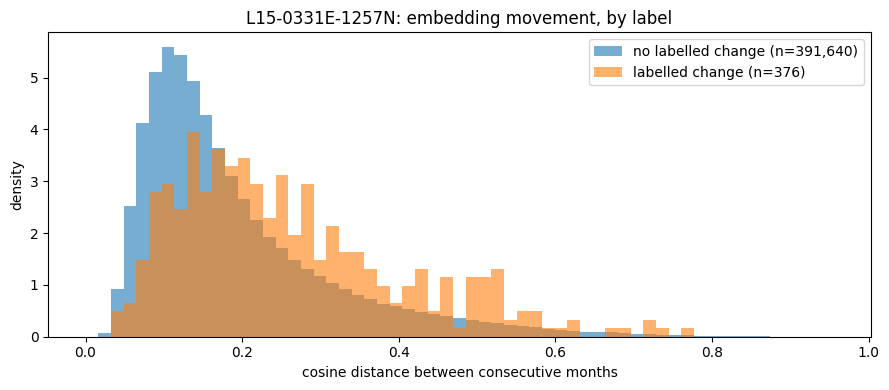

median distance: no change 0.153 | change 0.227


In [7]:
def cosine_distance_maps(features):
    """features (T, G, G, D) -> cosine distance between consecutive months, (T-1, G, G)."""
    f = F.normalize(features.to(device).float(), dim=-1)
    return (1 - (f[:-1] * f[1:]).sum(-1)).cpu()


sample_id = split["train"][0]
sample = data[sample_id]
distance = to_output_grid(cosine_distance_maps(sample["features"]))
keep, change = sample["keep"], sample["change"].bool()
no_change = distance[keep & ~change].numpy()
with_change = distance[keep & change].numpy()

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, max(float(distance[keep].max()), 1e-3), 60)
ax.hist(no_change, bins=bins, density=True, alpha=0.6, label=f"no labelled change (n={len(no_change):,})")
ax.hist(with_change, bins=bins, density=True, alpha=0.6, label=f"labelled change (n={len(with_change):,})")
ax.set_xlabel("cosine distance between consecutive months")
ax.set_ylabel("density")
ax.set_title(f"{sample_id[:15]}: embedding movement, by label")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cosine_distance_histogram.png", dpi=150)
plt.show()
print(f"median distance: no change {np.median(no_change):.3f} | change {np.median(with_change):.3f}")

## Step 7: Baseline 1, cosine-distance change detection (no training)

For every location and every consecutive month pair, the change score of a patch is the **cosine distance** between its two embeddings, `1 − cos(e_t, e_t+1)`. The 64×64 score map is upsampled to 128×128 and evaluated like any other detector.

A second version subtracts each pair's **median distance over the whole tile**. Seasonal and lighting changes move *every* patch's embedding a little; removing that shared shift leaves the patches that moved more than the rest.

No parameters are learned. The only "fitting" is the threshold, chosen on validation.

In [8]:
raw_maps, centred_maps = {}, {}
for loc_id, d in tqdm(data.items(), desc="Cosine distance"):
    patch = cosine_distance_maps(d["features"])
    raw_maps[loc_id] = to_output_grid(patch)
    centred_maps[loc_id] = to_output_grid(patch - patch.flatten(1).median(dim=1).values[:, None, None])

baselines.append(evaluate_detector(raw_maps, "Cosine distance (raw)"))
baselines.append(evaluate_detector(centred_maps, "Cosine distance (tile-median removed)"))

Cosine distance:   0%|          | 0/60 [00:00<?, ?it/s]

Cosine distance (raw): threshold 0.4225 | val F1 0.0248 | test P 0.0071 R 0.1251 F1 0.0135 IoU 0.0068
Cosine distance (tile-median removed): threshold 0.2671 | val F1 0.0428 | test P 0.0112 R 0.0743 F1 0.0194 IoU 0.0098


## Step 8: Baseline 2, cluster-switch change detection (no training)

k-means groups patches into `N_CLUSTERS` embedding clusters (fitted on 10,000 randomly chosen patches from every **training** location, across all its months). Each cluster loosely corresponds to a surface type such as dense buildings, bare soil, vegetation, or water. A patch whose cluster **differs between two months** is flagged as changed.

The score is the distance between a patch's embedding and its *previous* month's cluster centre, so a threshold can still be tuned. This is the kind of clustering analysis the embedding guidance describes, turned into a detector.

In [9]:
PATCHES_PER_LOCATION = 10_000
generator = torch.Generator().manual_seed(SEED)
sample = []
for loc_id in split["train"]:
    patches = data[loc_id]["features"].reshape(-1, FEATURE_DIM)
    idx = torch.randperm(len(patches), generator=generator)[:PATCHES_PER_LOCATION]
    sample.append(patches[idx].float())
sample = torch.cat(sample)
kmeans = MiniBatchKMeans(n_clusters=N_CLUSTERS, random_state=SEED, batch_size=4096, n_init=3)
kmeans.fit(sample.numpy())
centres = torch.from_numpy(kmeans.cluster_centers_).float().to(device)
print(f"Fitted k-means ({N_CLUSTERS} clusters) on {len(sample):,} patches from {len(split['train'])} training locations")
del sample

cluster_maps, switch_maps = {}, {}
for loc_id, d in tqdm(data.items(), desc="Cluster switches"):
    f = d["features"].to(device).float()
    T = f.shape[0]
    distances = torch.cdist(f.reshape(T, -1, FEATURE_DIM), centres[None].expand(T, -1, -1))
    labels = distances.argmin(-1).reshape(T, GRID, GRID)
    cluster_maps[loc_id] = labels.cpu()
    prev_centre_distance = distances[1:].gather(-1, labels[:-1].reshape(T - 1, -1, 1)).reshape(T - 1, GRID, GRID)
    switch_maps[loc_id] = to_output_grid((prev_centre_distance - distances[1:].min(-1).values.reshape(T - 1, GRID, GRID)).cpu())

baselines.append(evaluate_detector(switch_maps, f"Cluster switch (k-means, k={N_CLUSTERS})"))

Fitted k-means (8 clusters) on 420,000 patches from 42 training locations


Cluster switches:   0%|          | 0/60 [00:00<?, ?it/s]

Cluster switch (k-means, k=8): threshold 0.3218 | val F1 0.0363 | test P 0.0101 R 0.0934 F1 0.0182 IoU 0.0092


## Step 9: Embedding maps over time

The saved features are already PCA-projected, so their first three dimensions are the **three principal components** of DINOv3's patch embeddings. Shown as RGB, they give a rough "semantic map" of each month with no training. For one test location this shows, for six months: the image, the embedding map, and the k-means cluster map.

What to look for: the maps should stay almost identical month to month, apart from seasonal tint. Places where they change are where the embeddings moved, which is what both baselines detect.

Saved to `embedding_analysis/embedding_maps_<loc_id>.png`.

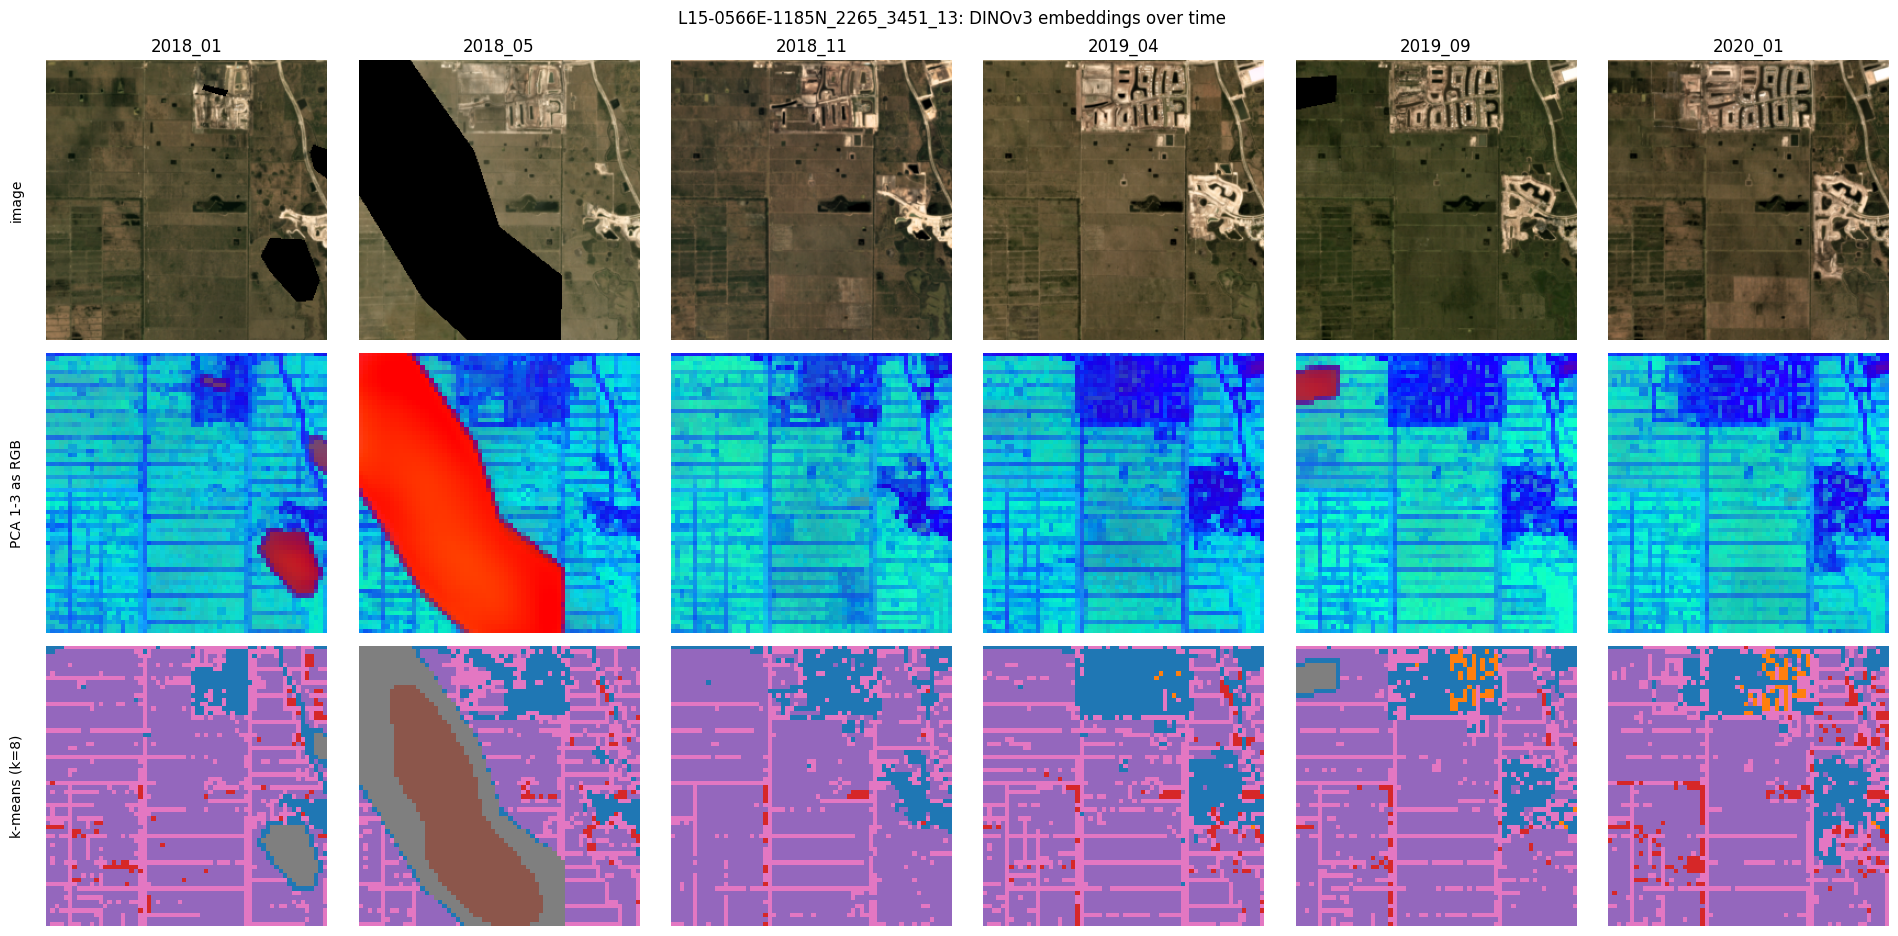

In [10]:
def read_rgb(loc_id, month, size=256):
    folder = DATA_ROOT / loc_id / "images_masked"
    if not folder.exists():
        folder = DATA_ROOT / loc_id / "images"
    path = next(folder.glob(f"global_monthly_{month}_*.tif"))
    with rasterio.open(path) as src:
        img = src.read([1, 2, 3], out_shape=(3, size, size), resampling=Resampling.bilinear)
    return np.transpose(img, (1, 2, 0))


viz_id = split["test"][0]
d = data[viz_id]
months = d["months"]
picks = np.linspace(0, len(months) - 1, 6).round().astype(int)

pcs = d["features"][..., :3].float()
lo, hi = pcs.flatten(0, 2).quantile(0.02, dim=0), pcs.flatten(0, 2).quantile(0.98, dim=0)
rgb = ((pcs - lo) / (hi - lo)).clamp(0, 1).numpy()

fig, axes = plt.subplots(3, len(picks), figsize=(3.2 * len(picks), 9.5))
for col, t in enumerate(picks):
    axes[0, col].imshow(read_rgb(viz_id, months[t]))
    axes[0, col].set_title(months[t])
    axes[1, col].imshow(rgb[t])
    axes[2, col].imshow(cluster_maps[viz_id][t].numpy(), cmap="tab10", vmin=0, vmax=9, interpolation="nearest")
    for row in range(3):
        axes[row, col].axis("off")
axes[0, 0].text(-0.08, 0.5, "image", transform=axes[0, 0].transAxes, rotation=90, va="center", ha="right")
axes[1, 0].text(-0.08, 0.5, "PCA 1-3 as RGB", transform=axes[1, 0].transAxes, rotation=90, va="center", ha="right")
axes[2, 0].text(-0.08, 0.5, f"k-means (k={N_CLUSTERS})", transform=axes[2, 0].transAxes, rotation=90, va="center", ha="right")
plt.suptitle(f"{viz_id}: DINOv3 embeddings over time")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"embedding_maps_{viz_id}.png", dpi=150)
plt.show()

## Step 10: Similarity search by example

Embeddings make "find more like this" a single dot product. The query is the **"after" embedding of the patch with the strongest labelled change** in a test location, i.e. what newly built-up ground looks like to DINOv3. Its cosine similarity to every patch of every month of that location is computed, and the top matches are shown on the images.

If the search works, the top matches should be other built-up patches of the same kind, including the same patch in later months (once the buildings exist) but not in earlier ones. Following the embedding guidance, the search uses the raw vectors, no standardization, all dimensions weighted equally.

Saved to `embedding_analysis/similarity_search_<loc_id>.png`.

Query: L15-0566E-1185N_2265_3451_13, patch (1, 19), change between 2018_01 and 2018_02
Similarity of the same patch in every month (should jump after the change):
   18_01:0.03 18_02:1.00 18_03:0.97 18_04:0.89 18_05:0.86 18_07:0.92 18_08:0.93 18_10:0.91 18_11:0.91 19_01:0.90 19_02:0.87 19_03:0.90 19_04:0.85 19_05:0.89 19_06:0.75 19_07:0.78 19_09:0.87 19_10:0.78 19_11:0.88 19_12:0.91 20_01:0.88


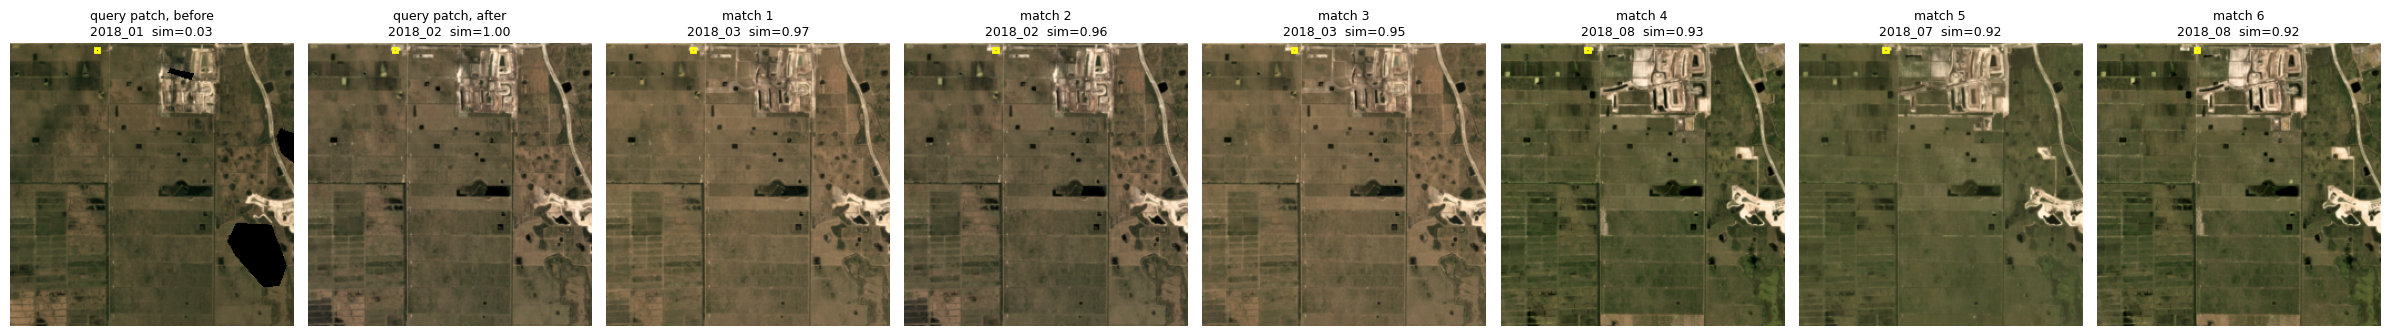

In [11]:
query_id = split["test"][0]
d = data[query_id]
months = d["months"]
change_pooled = F.adaptive_max_pool2d((d["change"] & d["keep"]).float().unsqueeze(1), GRID).squeeze(1)
t, y, x = np.unravel_index(int(change_pooled.argmax()), change_pooled.shape)
query = F.normalize(d["features"][t + 1, y, x].float(), dim=0)

all_patches = F.normalize(d["features"].float().reshape(-1, FEATURE_DIM), dim=-1)
similarity = (all_patches @ query).reshape(len(months), GRID, GRID)
flat = similarity.flatten()
top = torch.topk(flat, 7).indices[1:]  # skip the query patch itself
matches = [np.unravel_index(int(i), similarity.shape) for i in top]

query_month_scores = similarity[:, y, x]
print(f"Query: {query_id}, patch ({y}, {x}), change between {months[t]} and {months[t + 1]}")
print("Similarity of the same patch in every month (should jump after the change):")
print("   " + " ".join(f"{m[2:]}:{s:.2f}" for m, s in zip(months, query_month_scores.tolist())))

scale = 256 // GRID
fig, axes = plt.subplots(1, 8, figsize=(24, 3.6))
for ax, (tt, yy, xx), title in zip(axes, [(t, y, x), (t + 1, y, x)] + matches,
                                   ["query patch, before", "query patch, after"] + [f"match {i + 1}" for i in range(6)]):
    ax.imshow(read_rgb(query_id, months[tt]))
    ax.add_patch(plt.Rectangle((xx * scale, yy * scale), scale, scale, fill=False, edgecolor="yellow", linewidth=2))
    ax.set_title(f"{title}\n{months[tt]}  sim={similarity[tt, yy, xx]:.2f}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"similarity_search_{query_id}.png", dpi=150)
plt.show()

## Step 11: Compare everything

This collects `test_metrics.json` from every Part 3 run in `training/*/` and adds the training-free baselines from Steps 7 and 8. All rows use the same test locations and the same masked metrics, so they're directly comparable.

The table is printed, saved as `training/results_summary.json`, and as Markdown in `training/results_summary.md` ready to paste into the README.

In [14]:
# Runs live in training/<run_name>/. The first runs (before run folders existed) wrote to training/ itself
# and are labelled "grid32"; runs archived by 99_reset_training_run.ipynb are skipped.
metric_files = [p for p in TRAINING_DIR.glob("*/test_metrics.json") if not p.parent.name.startswith("archive_")]
if (TRAINING_DIR / "test_metrics.json").exists():
    metric_files.append(TRAINING_DIR / "test_metrics.json")

rows = []
for metrics_path in sorted(metric_files):
    m = json.loads(metrics_path.read_text())
    run_name = m.get("run_name", "grid32" if metrics_path.parent == TRAINING_DIR else metrics_path.parent.name)
    rows.append({
        "name": f"Trained: {run_name}",
        "details": f"{m.get('grid', '?')}x{m.get('grid', '?')} x {m.get('feature_dim', '?')}, "
                   f"{m.get('model_variant', 'baseline')}, focal+{m.get('loss_region', 'dice')}, best epoch {m['best_epoch']}",
        "threshold": m["threshold"], "val_f1": m["val"]["change"]["f1"], **{f"test_{k}": v for k, v in m["test"]["change"].items()},
        "test_building_iou": m["test"]["building"]["iou"],
    })
for b in baselines:
    rows.append({"name": b["name"], "details": f"no training, {FEATURES_SUBDIR}", "threshold": b["threshold"],
                 "val_f1": b["val"]["f1"], **{f"test_{k}": v for k, v in b["test"].items()}, "test_building_iou": None})
rows.sort(key=lambda r: -r["test_f1"])


def format_row(r):
    building = "" if r["test_building_iou"] is None else f"{r['test_building_iou']:.3f}"
    return (f"| {r['name']} | {r['details']} | {r['val_f1']:.3f} | {r['test_precision']:.3f} | {r['test_recall']:.3f} | "
            f"**{r['test_f1']:.3f}** | {r['test_iou']:.3f} | {building} |")


header = ("| Detector | Details | Val F1 | Test precision | Test recall | Test F1 | Test IoU | Building IoU |\n"
          "|---|---|---|---|---|---|---|---|\n")
table = header + "\n".join(format_row(r) for r in rows)
(TRAINING_DIR / "results_summary.json").write_text(json.dumps(rows, indent=2))
(TRAINING_DIR / "results_summary.md").write_text(table + "\n")
print(table)
print(f"\nSaved to {TRAINING_DIR / 'results_summary.md'}")

| Detector | Details | Val F1 | Test precision | Test recall | Test F1 | Test IoU | Building IoU |
|---|---|---|---|---|---|---|---|
| Trained: grid64_pca256 | 64x64 x 256, baseline, focal+dice, best epoch 26 | 0.219 | 0.199 | 0.160 | **0.178** | 0.097 | 0.704 |
| Trained: grid64_xattn_tversky | 64x64 x 256, xattn, focal+tversky, best epoch 25 | 0.215 | 0.170 | 0.183 | **0.176** | 0.096 | 0.679 |
| Trained: grid32 | ?x? x ?, baseline, focal+dice, best epoch 21 | 0.156 | 0.151 | 0.125 | **0.137** | 0.073 | 0.623 |
| Cosine distance (tile-median removed) | no training, features_1024_pca256 | 0.043 | 0.011 | 0.074 | **0.019** | 0.010 |  |
| Cluster switch (k-means, k=8) | no training, features_1024_pca256 | 0.036 | 0.010 | 0.093 | **0.018** | 0.009 |  |
| Cosine distance (raw) | no training, features_1024_pca256 | 0.025 | 0.007 | 0.125 | **0.013** | 0.007 |  |

Saved to /content/drive/MyDrive/datasets/spacenet7_cache/training/results_summary.md
